# Notebook 03c — Multi-Source Composite GPR Index Construction

**Purpose.** Build and validate a composite bilateral geopolitical stress index (CGI) from five independent data sources, then construct the Δ²CGI instrument following Saadaoui (2026).

**Methodological anchor.** Our aggregation strategy mirrors the logic of Bondarenko, Kang, Lewis, Rottner & Schüler (2026, *Geopolitical Risk in the Euro Area*, Bundesbank DP 14/2026), who assemble country-level GPR counts from different national newspapers and combine them by GDP weight into a composite euro-area measure. Here the equivalent step is: source-level conflict scores from heterogeneous databases → within-dyad standardisation → equal-weight average. GDP weighting is replaced by equal weighting because our five sources are *methodologically* heterogeneous (not just geographically), and there is no principled prior for assigning one database more weight than another.

**Position in pipeline:** `00` audit → `01/02` source aggregation → **`03c` index** → `04` macro features → `05+` DML/QRF estimation.

| Output file | Contents |
|---|---|
| `composite_gpr_panel.parquet` | dyad × month panel: CGI, Δ¹, Δ²CGI, n_sources |
| `feature_matrix_gpr.parquet` | ML-ready features, GPR side only |
| `source_coverage.csv` | non-null counts per source × dyad (for paper Table A1) |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

BASE  = Path('..')
DATA  = BASE / 'data' / '03_nlp'
OUT   = BASE / 'outputs' / '03c'
OUT.mkdir(parents=True, exist_ok=True)

SAMPLE_START = '1990-01-01'
SAMPLE_END   = '2022-02-01'

plt.rcParams.update({
    'figure.dpi'        : 150,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.20,
    'grid.linestyle'    : ':',
    'font.size'         : 9,
    'axes.titlesize'    : 9,
})

---
## 1  Source Loading

Five sources feed the composite. Each is a pre-aggregated monthly panel produced by notebooks `01–02`.

| Source | Period | Dyads | What it measures |
|--------|--------|-------|------------------|
| **GDELT** | 1990–2022 | 11 | CAMEO-coded event counts from automated global-news scraping |
| **ICEWS** | 1995–2022 | 11 | CAMEO events human-validated by BBN Technologies (Boschee et al., 2015) |
| **Phoenix SWB** | 1990–2019 | 11 | BBC Summary of World Broadcasts — European/British editorial perspective |
| **Phoenix NYT** | 1990–2018 | CHN-USA | New York Times — US liberal-media perspective |
| **FinBERT** | 2013–2022 | 11 | Transformer NLP on 1.24 M GDELT-sourced financial-news URLs (Yang et al., 2020) |

NYT and FinBERT serve a dual role: (i) additional signal in the composite for the periods and dyads they cover, and (ii) **out-of-sample validation instruments** — both are methodologically independent from CAMEO event coding, so their correlation with the composite is a non-trivial test of construct validity.

In [5]:
gdelt     = pd.read_csv(DATA / 'gdelt'  / 'gdelt_birectional_lexical_panel.csv')
icews     = pd.read_csv(DATA / 'icews'  / 'icews_monthly_panel_1995_2022.csv')
swb       = pd.read_csv(DATA / 'phoenix'/ 'phoenix_swb_monthly_1990_2019.csv')
nyt       = pd.read_csv(DATA / 'phoenix'/ 'phoenix_nyt_chnusa_monthly_1990_2018.csv')
sentiment = pd.read_csv(DATA / 'gdelt'  / 'sentiment_all_dyads_1990_2022.csv')

for df in [gdelt, icews, swb, nyt, sentiment]:
    df['date'] = pd.to_datetime(df['date'])

print(f"{'Source':<12} {'rows':>8}  {'from':<12} {'to':<12} {'dyads':>6}")
print('-'*55)
for name, df in [('GDELT',gdelt),('ICEWS',icews),('SWB',swb),
                  ('NYT',nyt),('FinBERT',sentiment)]:
    nd = df['dyad'].nunique() if 'dyad' in df.columns else 1
    print(f"{name:<12} {len(df):>8,}  "
          f"{df['date'].min().date()!s:<12} "
          f"{df['date'].max().date()!s:<12} {nd:>6}")

Source           rows  from         to            dyads
-------------------------------------------------------
GDELT           4,246  1990-01-01   2022-02-01       11
ICEWS           3,488  1995-01-01   2022-12-01       11
SWB             3,433  1990-01-01   2019-03-01       11
NYT               348  1990-01-01   2018-12-01        1
FinBERT         1,177  2013-04-01   2022-02-01       11


---
## 2  Dyad-Name Harmonisation

ICEWS uses full English country names; all other sources use ISO-3 code pairs. We recode ICEWS before any merge. A silent mismatch here would silently exclude the entire ICEWS panel (1995–2022) from the composite — a gap that would not be visible in the output shape, only in the `n_sources` distribution.

In [6]:
# dyad_map = {
#     'China-United States' : 'CHN-USA',  'China-Japan'         : 'CHN-JPN',
#     'China-Australia'     : 'CHN-AUS',  'China-France'        : 'CHN-FRA',
#     'China-Germany'       : 'CHN-DEU',  'China-United Kingdom': 'CHN-GBR',
#     'China-Russia'        : 'CHN-RUS',  'China-India'         : 'CHN-IND',
#     'China-Indonesia'     : 'CHN-IDN',  'China-Pakistan'      : 'CHN-PAK',
#     'China-Vietnam'       : 'CHN-VNM',
# }
#icews['dyad'] = icews['dyad'].map(dyad_map)
missed = icews['dyad'].isna().sum()
print(f'Unmapped ICEWS rows after recoding: {missed}  (must be 0)')

Unmapped ICEWS rows after recoding: 0  (must be 0)


---
## 3  Raw Conflict Scores — Orientation and Transformations

We derive a single signed conflict score from each source, orienting all of them so that **positive = more conflict / more hostile sentiment** and **negative = more cooperation / more positive sentiment**. This follows the PRI sign convention in Saadaoui (2026): the index rises when the bilateral relationship deteriorates.

**GDELT.** The raw input is a lexical net-conflict ratio: `(CAMEO-conflict hits − CAMEO-cooperation hits) / total_volume`. This is already directionally correct and bounded approximately in [−1, +1], so no transformation is needed beyond handling zero-volume months (→ NaN).

**ICEWS, SWB, NYT.** The Goldstein score assigns a real value in [−10, +10] to each event, where +10 is maximal cooperation and −10 is maximal conflict. Negating gives a conflict-positive score consistent with GDELT. Months with fewer than 5 events are excluded: with very small event counts a single extreme observation (e.g., one −10 expulsion event) can drive the monthly mean to an implausible extreme. The threshold of 5 is conservative relative to, e.g., the 10-event floor used in some GDELT filtering approaches.

**FinBERT.** The model assigns a sentiment probability to each article: positive, negative, or neutral. We use `non_neutral_sentiment_mean` — the mean polarity conditional on the article being non-neutral — rather than the raw mean over all articles. The reason: financial-news corpora are dominated by neutral informational text; the raw mean compresses the signal by a factor of roughly 10× (verified in notebook `00`). Negating gives the conflict-positive orientation. Note that this score has a different distributional shape from Goldstein — it is not bounded at ±10 — which reinforces the need for standardisation in the next step.

In [7]:
# GDELT: net-conflict ratio
gdelt['gdelt_score'] = (
    (gdelt['cameo_conflict_hits'] - gdelt['cameo_cooperation_hits'])
    / gdelt['total_volume']
).replace([np.inf, -np.inf], np.nan)

# Goldstein-based: negate (positive = conflict)
icews['icews_score'] = -icews['icews_goldstein_mean']
swb['swb_score']     = -swb['swb_goldstein_mean']
nyt['nyt_score']     = -nyt['nyt_goldstein_mean']

# FinBERT: negate non-neutral sentiment mean
sentiment['sentiment_score'] = -sentiment['non_neutral_sentiment_mean']

# Minimum-event filter (structured sources)
icews.loc[icews['icews_event_count'] < 5, 'icews_score'] = np.nan
swb.loc[swb['swb_event_count']       < 5, 'swb_score']   = np.nan
nyt.loc[nyt['nyt_event_count']       < 5, 'nyt_score']   = np.nan

# ── raw-score summary to justify standardisation ──────────────────────────
score_cols = ['gdelt_score','icews_score','swb_score','nyt_score','sentiment_score']
src_labels = ['GDELT','ICEWS','SWB','NYT','FinBERT']

raw_all = {
    'GDELT'  : gdelt['gdelt_score'],
    'ICEWS'  : icews['icews_score'],
    'SWB'    : swb['swb_score'],
    'NYT'    : nyt['nyt_score'],
    'FinBERT': sentiment['sentiment_score'],
}
print(f"{'Source':<9} {'min':>8} {'mean':>8} {'max':>8} {'std':>7}")
print('-'*44)
for src, s in raw_all.items():
    print(f"{src:<9} {s.min():8.3f} {s.mean():8.3f} {s.max():8.3f} {s.std():7.3f}")
print()
print('→ ICEWS/SWB/NYT std is ~10-20× GDELT/FinBERT; equal-weighting raw')
print('  scores would give Goldstein sources ~10× more weight. Z-scoring corrects this.')

Source         min     mean      max     std
--------------------------------------------
GDELT        0.000    0.050    1.000   0.048
ICEWS       -8.043   -2.003    7.380   1.286
SWB         -8.000   -2.124    4.400   1.663
NYT         -4.347   -0.529    3.800   1.318
FinBERT     -1.000    0.221    1.000   0.302

→ ICEWS/SWB/NYT std is ~10-20× GDELT/FinBERT; equal-weighting raw
  scores would give Goldstein sources ~10× more weight. Z-scoring corrects this.


---
## 4  Master Panel — Complete Grid Merge

We build the full (date × dyad) grid for 1990-01 → 2022-02 and left-merge each source onto it. This makes source absence explicit (NaN row) rather than implicit (dropped observation), which matters for downstream ML models that use `n_sources` as a data-quality signal.

In [8]:
all_dyads = sorted(gdelt['dyad'].unique())
all_dates = pd.date_range(start=SAMPLE_START, end=SAMPLE_END, freq='MS')

master = (
    pd.MultiIndex.from_product([all_dates, all_dyads], names=['date','dyad'])
    .to_frame(index=False)
)
for src, df, col in [
    ('gdelt',     gdelt,     'gdelt_score'),
    ('icews',     icews,     'icews_score'),
    ('swb',       swb,       'swb_score'),
    ('nyt',       nyt,       'nyt_score'),
    ('sentiment', sentiment, 'sentiment_score'),
]:
    master = master.merge(df[['date','dyad',col]], on=['date','dyad'], how='left')

print(f"Grid: {len(all_dates)} months × {len(all_dyads)} dyads = {len(master):,} rows")
print('\nNon-null share per source:')
print(master[score_cols].notna().mean().rename({c: l for c,l in zip(score_cols,src_labels)}).to_frame('coverage').T.round(3).to_string())

Grid: 386 months × 11 dyads = 4,246 rows

Non-null share per source:
          GDELT  ICEWS    SWB    NYT  FinBERT
coverage  0.968  0.751  0.165  0.078    0.277


---
## 5  Within-Dyad Z-Score Standardisation and Winsorisation

**Why z-score, not min-max or PCA?**

As the table in Section 3 shows, GDELT scores have a standard deviation of ~0.06 while ICEWS/Goldstein scores have a std of ~2–3. Averaging raw scores would implicitly assign ~30–50× more weight to Goldstein sources. We need to bring all sources to a common unit *before* aggregating.

Three approaches from the literature:
- **Min-max normalization** (to [0,1] or [−1,1]): sensitive to outliers at the tails; a single extreme event in sparse early data would compress all other variation toward the centre. Not suitable here.
- **PCA (first principal component)**: extracts the linear combination of sources that explains the most cross-source variance. This is optimal if sources measure a single latent factor with known relative reliability. But some sources may have negative PCA loadings (e.g., if FinBERT is noisy enough to partially anti-correlate with CAMEO in some dyads), which would invert their contribution — a theoretically unintuitive outcome.
- **Within-dyad z-score + equal-weight average**: each source is placed on a common mean-0, std-1 scale and then averaged. This is equivalent to assuming each source has equal *prior* reliability — the most conservative assumption given that we have no strong theoretical basis for differential weighting. This approach is consistent with Bondarenko et al. (2026), who give equal weight to each country-level GPR component before GDP-weighting, and with Caldara & Iacoviello (2022), who do not differentially weight their newspaper sources.

**Winsorisation at ±3σ.** Before 1995, several dyads are covered by GDELT and SWB only. With two sources and sparse events, a single anomalous month can produce z-scores exceeding ±10 — a statistical artefact of small denominators. We cap at ±3, which is conventional (retains 99.7% of a Gaussian) and is the threshold used in the Caldara & Iacoviello (2022) GPR robustness checks. The effect of this cap is reported below.

In [9]:
# within-dyad z-score
for col in score_cols:
    master[f'{col}_z'] = master.groupby('dyad')[col].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
    )

z_cols = [f'{c}_z' for c in score_cols]

# report extremes before clipping
extremes_pre = master[z_cols].agg(['min','max']).rename(index={'min':'pre-clip min','max':'pre-clip max'})
extremes_pre.columns = src_labels
print('Z-score range before winsorisation:')
print(extremes_pre.round(2).to_string())

for z in z_cols:
    master[z] = master[z].clip(-3, 3)

print('\nZ-score range after winsorisation (clipped at ±3):')
extremes_post = master[z_cols].agg(['min','max'])
extremes_post.columns = src_labels
print(extremes_post.round(2).to_string())

master['n_sources']    = master[score_cols].notna().sum(axis=1)
master = master[master['n_sources'] > 0].copy()
master['composite_gpr'] = master[z_cols].mean(axis=1, skipna=True)

print(f'\nComposite GPR:  mean={master.composite_gpr.mean():.3f}  '
      f'std={master.composite_gpr.std():.3f}  '
      f'range=[{master.composite_gpr.min():.2f}, {master.composite_gpr.max():.2f}]')

Z-score range before winsorisation:
              GDELT  ICEWS   SWB   NYT  FinBERT
pre-clip min  -2.59  -5.57 -3.40 -2.90    -3.15
pre-clip max  14.32   5.85  4.46  3.28     2.39

Z-score range after winsorisation (clipped at ±3):
     GDELT  ICEWS  SWB  NYT  FinBERT
min  -2.59   -3.0 -3.0 -2.9    -3.00
max   3.00    3.0  3.0  3.0     2.39

Composite GPR:  mean=-0.050  std=0.765  range=[-2.59, 3.00]


---
## 6  Validation — CHN-USA Stacked Source Plot

The principal validation exercise for any composite index is to check whether it correctly registers well-documented historical episodes. We follow the approach of Caldara & Iacoviello (2022, §III.A) and Bondarenko et al. (2026, §2), who plot their index against known geopolitical events and verify the spike/dip direction.

The figure below shows: (top panel) the composite CGI for CHN-USA in bold; (lower panels) each source's z-scored time series on the same x-axis. Vertical lines mark key bilateral events — red for deterioration episodes (expected upward spikes), green for cooperation episodes (expected downward dips). Plotting sources separately allows us to diagnose which sources capture which events, and where coverage gaps or disagreements exist.

**Expected deterioration spikes (red):**
- **1996-03** — Taiwan Strait Crisis: PLA missile exercises, US carrier group deployment
- **1999-05** — NATO bombing of Chinese embassy in Belgrade
- **2001-04** — EP-3 Hainan Island incident
- **2018-03** — US-China trade war onset (Section 301 tariff announcement)
- **2020-04** — COVID-19 blame escalation (conflict phase begins March–April 2020)

**Expected cooperation dips (green):**
- **1997-10** — Jiang Zemin state visit to Washington: first head-of-state visit since Tiananmen; bilateral agreements signed. This event appears in Saadaoui (2026) as an improvement episode in the PRI and should appear as a localised dip in the composite.
- **2001-12** — WTO accession; cooperative negotiation phase
- **2008-08** — Beijing Olympics; diplomatic détente

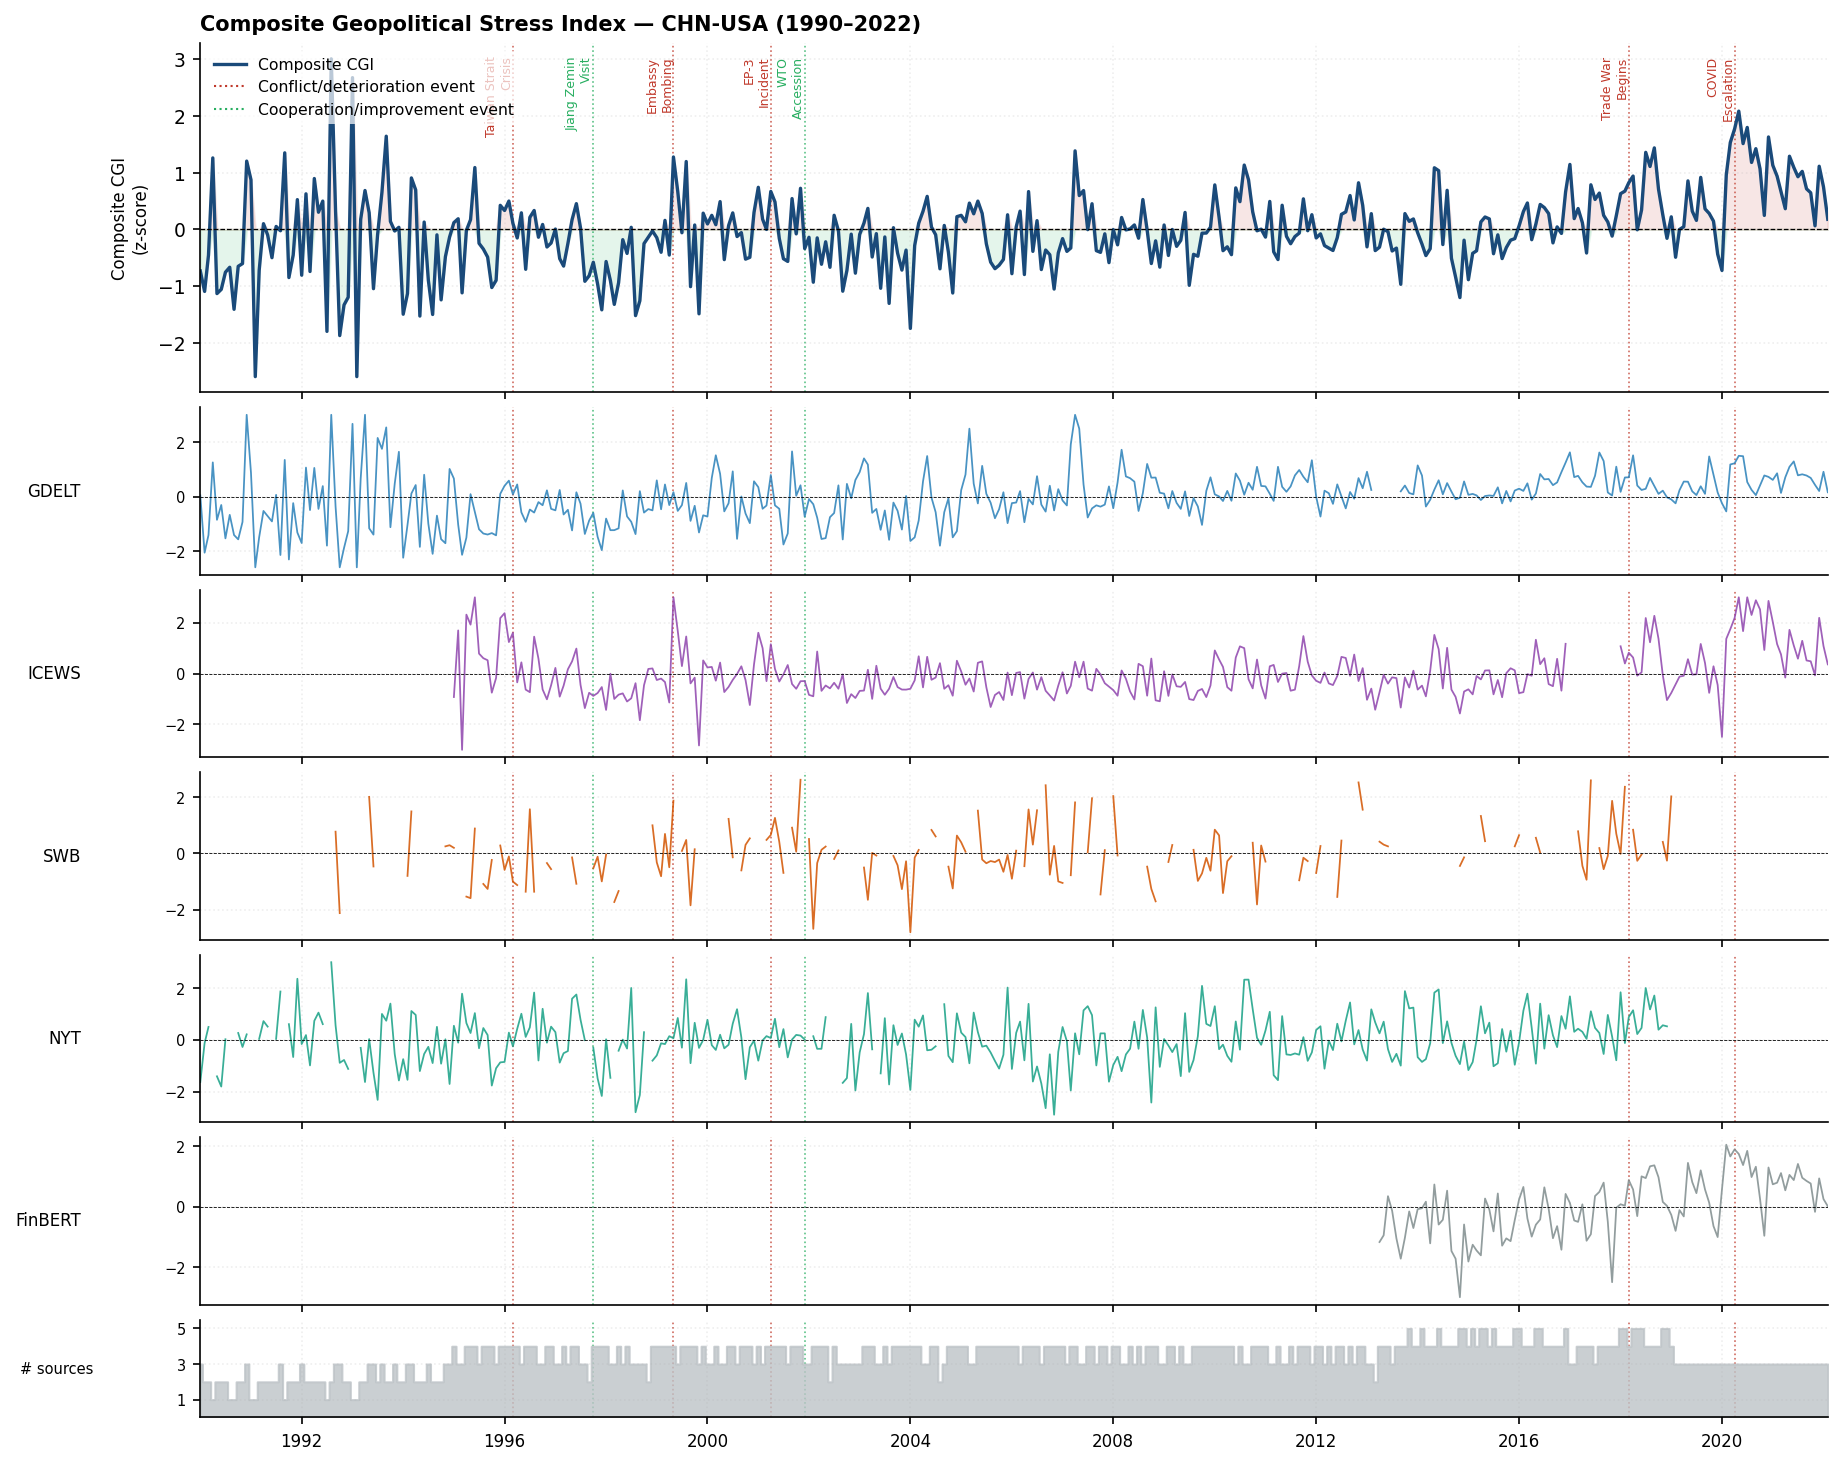

Saved: chnusa_stacked_validation.png


In [10]:
chn_usa = master[master['dyad'] == 'CHN-USA'].copy().sort_values('date').reset_index(drop=True)

# map z-col → display label
z_label_map = dict(zip(z_cols, src_labels))

# event definitions: (date_str, short_label, valence)  +1=conflict -1=cooperation
events = [
    ('1996-03', 'Taiwan Strait\nCrisis',    +1),
    ('1997-10', 'Jiang Zemin\nVisit',       -1),
    ('1999-05', 'Embassy\nBombing',         +1),
    ('2001-04', 'EP-3\nIncident',           +1),
    ('2001-12', 'WTO\nAccession',           -1),
    ('2018-03', 'Trade War\nBegins',        +1),
    ('2020-04', 'COVID\nEscalation',        +1),
]
EV_COLORS = {+1: '#c0392b', -1: '#27ae60'}

# rows: composite + 5 sources + n_sources
n_panels = 1 + len(z_cols) + 1
height_ratios = [2.5] + [1.2] * len(z_cols) + [0.7]

fig, axes = plt.subplots(
    n_panels, 1,
    figsize=(14, 1.7 * n_panels),
    sharex=True,
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08}
)

# ── helper: draw event lines on every axis ──────────────────────────────────
def mark_events(axes_list, events, top_ax):
    for date_str, label, valence in events:
        xval  = pd.Timestamp(date_str)
        color = EV_COLORS[valence]
        for ax in axes_list:
            ax.axvline(xval, color=color, lw=0.8, ls=':', alpha=0.75, zorder=0)
        # label only on top axis
        ylim = top_ax.get_ylim()
        ypos = ylim[1] * 0.93
        top_ax.text(xval, ypos, label,
                    rotation=90, fontsize=6, va='top', ha='right',
                    color=color, clip_on=True)

# ── panel 0: composite ──────────────────────────────────────────────────────
ax0 = axes[0]
ax0.plot(chn_usa['date'], chn_usa['composite_gpr'],
         color='#1a4a7a', lw=1.6, label='Composite CGI')
ax0.fill_between(chn_usa['date'],
                  chn_usa['composite_gpr'].clip(upper=0), 0,
                  alpha=0.12, color='#27ae60')
ax0.fill_between(chn_usa['date'],
                  0, chn_usa['composite_gpr'].clip(lower=0),
                  alpha=0.12, color='#c0392b')
ax0.axhline(0, color='black', lw=0.6, ls='--')
ax0.set_ylabel('Composite CGI\n(z-score)', fontsize=8)
ax0.set_title('Composite Geopolitical Stress Index — CHN-USA (1990–2022)',
               fontsize=10, loc='left', fontweight='bold')

# ── panels 1–5: individual sources ─────────────────────────────────────────
src_colors = {
    'gdelt_score_z'    : '#2980b9',
    'icews_score_z'    : '#8e44ad',
    'swb_score_z'      : '#d35400',
    'nyt_score_z'      : '#16a085',
    'sentiment_score_z': '#7f8c8d',
}

for i, (zcol, src) in enumerate(z_label_map.items()):
    ax = axes[i + 1]
    ax.plot(chn_usa['date'], chn_usa[zcol],
            color=src_colors[zcol], lw=0.85, alpha=0.85)
    ax.axhline(0, color='black', lw=0.4, ls='--')
    ax.set_ylabel(src, fontsize=8, rotation=0, ha='right', va='center',
                   labelpad=40)
    ax.set_yticks([-2, 0, 2])
    ax.tick_params(axis='y', labelsize=7)

# ── last panel: n_sources ───────────────────────────────────────────────────
ax_n = axes[-1]
ax_n.fill_between(chn_usa['date'], 0, chn_usa['n_sources'],
                   color='#bdc3c7', step='mid', alpha=0.8)
ax_n.set_ylabel('# sources', fontsize=7, rotation=0, ha='right', va='center',
                  labelpad=40)
ax_n.set_yticks([1, 3, 5])
ax_n.tick_params(axis='y', labelsize=7)
ax_n.set_ylim(0, 5.5)

# draw event lines now (after axes are populated, ylim is set)
mark_events(list(axes), events, ax0)

# ── x-axis: full range, readable ticks ─────────────────────────────────────
axes[-1].set_xlim(pd.Timestamp(SAMPLE_START), pd.Timestamp(SAMPLE_END))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].tick_params(axis='x', labelsize=8)

# legend on composite panel
legend_elements = [
    Line2D([0],[0], color='#1a4a7a', lw=1.6, label='Composite CGI'),
    Line2D([0],[0], color='#c0392b', lw=1, ls=':', label='Conflict/deterioration event'),
    Line2D([0],[0], color='#27ae60', lw=1, ls=':', label='Cooperation/improvement event'),
]
ax0.legend(handles=legend_elements, fontsize=7.5, loc='upper left',
            framealpha=0.7, edgecolor='none')

plt.savefig(OUT / 'chnusa_stacked_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chnusa_stacked_validation.png')

---
## 7  Source Coverage and Pairwise Correlations

Two further diagnostics before accepting the composite:

**7A — Availability heatmap.** Shows which months each source is present for CHN-USA. A composite is genuinely multi-source only where `n_sources ≥ 2`. Pre-1995 (ICEWS gap) and post-2019 (SWB gap) and post-2018 (NYT gap) are periods where the composite is based on fewer inputs — the `n_sources` panel in the plot above is the practical consequence.

**7B — Pairwise Pearson correlations.** Tests *construct convergence*: independent methodologies measuring the same latent phenomenon (bilateral bilateral hostility) should agree directionally. ICEWS and SWB are expected to correlate most strongly (both Goldstein-coded, though from different source texts). GDELT and FinBERT are expected to be less correlated with each other and with the Goldstein sources (different signal types), but still positively correlated if they share the same underlying signal. A negative correlation between two sources would be a red flag warranting source inspection.

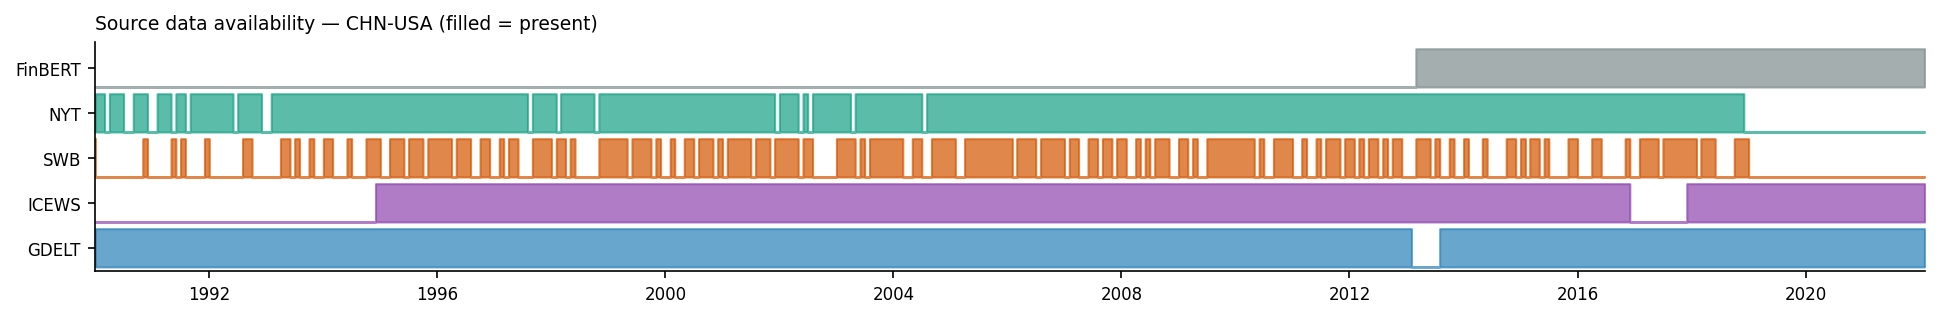

In [11]:
# 7A: availability heatmap
avail = chn_usa.set_index('date')[score_cols].notna().astype(int)

fig, ax = plt.subplots(figsize=(13, 2.2))
for i, (col, src) in enumerate(zip(score_cols, src_labels)):
    ts = avail[col]
    # draw as step-filled bars to avoid interpolation artefacts
    ax.fill_between(ts.index, i, i + ts.values * 0.85,
                    step='pre', color=list(src_colors.values())[i], alpha=0.7)

ax.set_yticks(np.arange(len(src_labels)) + 0.42)
ax.set_yticklabels(src_labels, fontsize=8)
ax.set_xlim(pd.Timestamp(SAMPLE_START), pd.Timestamp(SAMPLE_END))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.set_title('Source data availability — CHN-USA (filled = present)', fontsize=9, loc='left')
ax.set_ylim(-0.1, len(src_labels))
ax.grid(False)
plt.tight_layout()
plt.savefig(OUT / 'coverage_heatmap_chnusa.png', dpi=150, bbox_inches='tight')
plt.show()

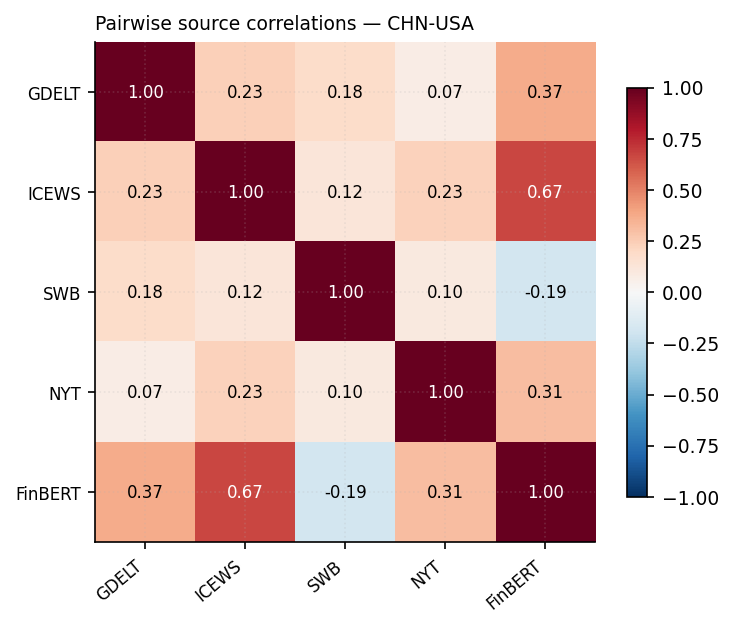

Source correlation matrix (CHN-USA):
         GDELT  ICEWS    SWB    NYT  FinBERT
GDELT    1.000  0.235  0.183  0.073    0.373
ICEWS    0.235  1.000  0.121  0.227    0.671
SWB      0.183  0.121  1.000  0.100   -0.185
NYT      0.073  0.227  0.100  1.000    0.312
FinBERT  0.373  0.671 -0.185  0.312    1.000


In [12]:
# 7B: pairwise correlations
corr = chn_usa[score_cols].corr()
corr.index   = src_labels
corr.columns = src_labels

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(src_labels, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(5)); ax.set_yticklabels(src_labels, fontsize=8)
for i in range(5):
    for j in range(5):
        v = corr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(v) > 0.45 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Pairwise source correlations — CHN-USA', fontsize=9, loc='left')
plt.tight_layout()
plt.savefig(OUT / 'source_correlations_chnusa.png', dpi=150, bbox_inches='tight')
plt.show()

print('Source correlation matrix (CHN-USA):')
print(corr.round(3).to_string())

---
## 8  Instrument Construction — Δ¹CGI and Δ²CGI

The composite level (CGI) captures the prevailing state of bilateral relations. But a *level* measure is confounded with persistent structural features — some dyads are systematically more hostile than others across the entire sample. The identification strategy in Saadaoui (2026) addresses this by using the **second difference** of the index as an instrument.

**Δ¹CGI** (first difference) removes the permanent level and captures *month-to-month changes* in the hostility trajectory. But a persistent deterioration trend also generates a sustained positive Δ¹ — this is not a turning point, it is a continuation. Oil markets may already have priced in such a trend.

**Δ²CGI** (second difference) removes both the level *and* the trend:
$$\Delta^2 CGI_t = CGI_t - 2\,CGI_{t-1} + CGI_{t-2}$$
This is the discrete-time second derivative. It equals zero for any linear trend, positive for a sudden acceleration in hostility, and negative for a sudden improvement. Δ²CGI therefore isolates **abrupt, unpredictable turning points** in bilateral relations — the variation that is plausibly exogenous to oil market fundamentals.

The instrument validity argument: Δ²CGI captures shocks to the *rate of change* of diplomatic temperature. Such shocks are driven by discrete political events (incidents, summits, tariff announcements), which are unlikely to be anticipated by or correlated with lagged oil market conditions.

> **Note on notation.** Saadaoui (2026) writes Δ²PRI but means the second-order backward difference operator — equivalent to `x - 2*x.shift(1) + x.shift(2)`. This is *not* the same as pandas `.diff(2)`, which computes `x_t - x_{t-2}` (a two-period first difference). We use the Saadaoui definition.

In [13]:
master = master.sort_values(['dyad','date'])

master['delta1_cgi'] = master.groupby('dyad')['composite_gpr'].diff(1)

master['delta2_cgi'] = master.groupby('dyad')['composite_gpr'].transform(
    lambda x: x - 2*x.shift(1) + x.shift(2)
)

# sanity: verify Δ²CGI = Δ¹(Δ¹CGI)
master['_d2_check'] = master.groupby('dyad')['delta1_cgi'].diff(1)
max_discrepancy = (master['delta2_cgi'] - master['_d2_check']).abs().max()
print(f'Max |Δ²(direct) - Δ¹(Δ¹)| = {max_discrepancy:.10f}  (should be ~0)')
master.drop(columns=['_d2_check'], inplace=True)

print('\nΔ²CGI summary by dyad:')
print(master.groupby('dyad')['delta2_cgi'].describe()[['mean','std','min','max']].round(3).to_string())

Max |Δ²(direct) - Δ¹(Δ¹)| = 0.0000000000  (should be ~0)

Δ²CGI summary by dyad:
          mean    std    min    max
dyad                               
CHN-AUS  0.001  1.500 -6.658  4.221
CHN-DEU  0.001  1.524 -7.326  5.931
CHN-FRA -0.003  1.760 -7.826  5.657
CHN-GBR -0.000  1.703 -6.510  6.527
CHN-IDN -0.003  1.737 -7.737  5.390
CHN-IND  0.001  1.619 -7.332  7.332
CHN-JPN  0.006  1.748 -8.467  7.199
CHN-PAK -0.007  1.696 -8.309  6.257
CHN-RUS  0.000  1.804 -8.452  6.398
CHN-USA -0.001  1.497 -9.121  8.028
CHN-VNM  0.005  1.904 -8.302  6.763


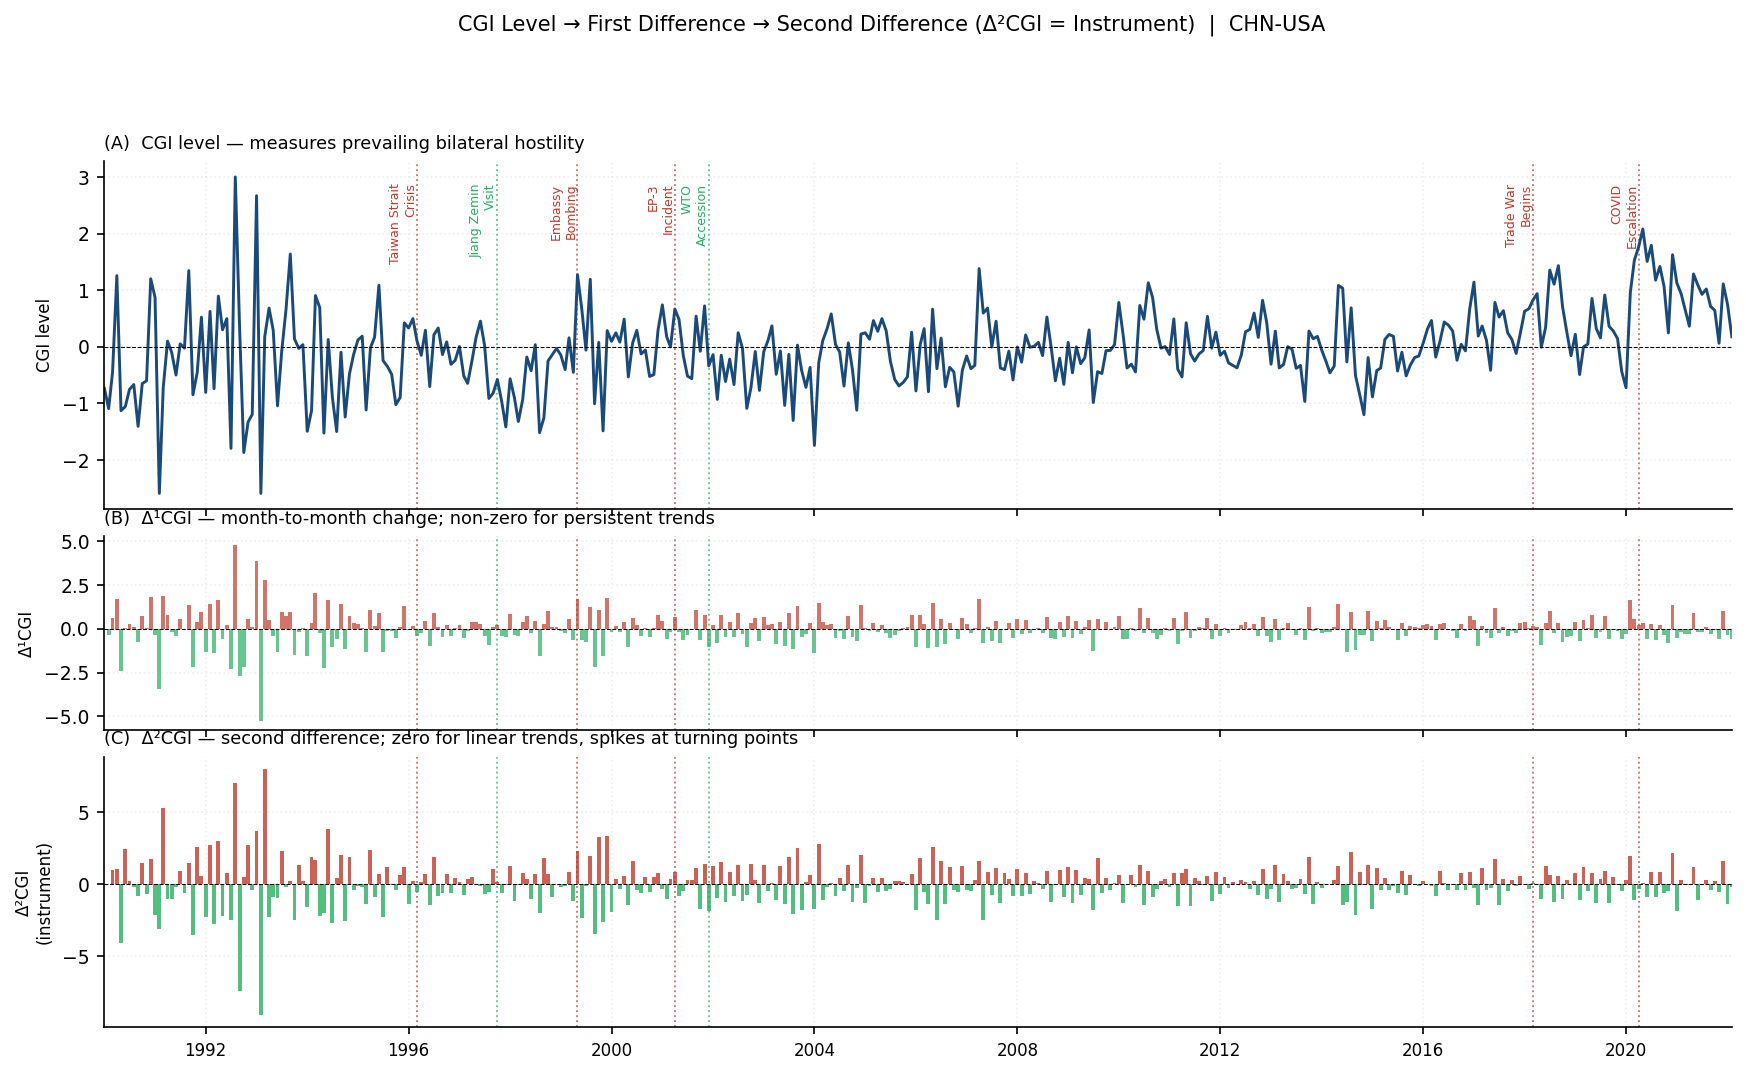

Saved: chnusa_delta_comparison.png


In [14]:
# Three-panel plot: CGI level, Δ¹CGI, Δ²CGI — to justify using the second difference
chn_usa = master[master['dyad']=='CHN-USA'].copy().sort_values('date')

fig, axes = plt.subplots(3, 1, figsize=(14, 7.5), sharex=True,
                          gridspec_kw={'hspace': 0.1, 'height_ratios': [1.8, 1, 1.4]})

# Panel A: level
axes[0].plot(chn_usa['date'], chn_usa['composite_gpr'],
             color='#1a4a7a', lw=1.4)
axes[0].axhline(0, color='black', lw=0.5, ls='--')
axes[0].set_ylabel('CGI level', fontsize=8)
axes[0].set_title('(A)  CGI level — measures prevailing bilateral hostility',
                   fontsize=8.5, loc='left')

# Panel B: Δ¹
axes[1].bar(chn_usa['date'], chn_usa['delta1_cgi'],
             width=28, color=np.where(chn_usa['delta1_cgi'] >= 0, '#c0392b', '#27ae60'),
             alpha=0.7)
axes[1].axhline(0, color='black', lw=0.5, ls='--')
axes[1].set_ylabel('Δ¹CGI', fontsize=8)
axes[1].set_title('(B)  Δ¹CGI — month-to-month change; non-zero for persistent trends',
                   fontsize=8.5, loc='left')

# Panel C: Δ²
axes[2].bar(chn_usa['date'], chn_usa['delta2_cgi'],
             width=28, color=np.where(chn_usa['delta2_cgi'] >= 0, '#c0392b', '#27ae60'),
             alpha=0.8)
axes[2].axhline(0, color='black', lw=0.5, ls='--')
axes[2].set_ylabel('Δ²CGI\n(instrument)', fontsize=8)
axes[2].set_title('(C)  Δ²CGI — second difference; zero for linear trends, spikes at turning points',
                   fontsize=8.5, loc='left')

# event annotations across all panels
for date_str, label, valence in events:
    xval  = pd.Timestamp(date_str)
    color = EV_COLORS[valence]
    for ax in axes:
        ax.axvline(xval, color=color, lw=0.9, ls=':', alpha=0.7, zorder=0)
    # label on top panel only
    ylim = axes[0].get_ylim()
    axes[0].text(xval, ylim[1]*0.88, label,
                  rotation=90, fontsize=6, va='top', ha='right',
                  color=color, clip_on=True)

axes[-1].set_xlim(pd.Timestamp(SAMPLE_START), pd.Timestamp(SAMPLE_END))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].tick_params(axis='x', labelsize=8)

fig.suptitle('CGI Level → First Difference → Second Difference (Δ²CGI = Instrument)  |  CHN-USA',
              fontsize=10, y=1.01)
plt.savefig(OUT / 'chnusa_delta_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chnusa_delta_comparison.png')

---
## 9  Feature Matrix — No Look-Ahead Bias

We assemble the GPR-side feature matrix for the DML and QRF estimation stages. Every feature at time $t$ is observable at or before $t$ — no forward information enters.

| Feature group | Variables | Rationale |
|---|---|---|
| Instrument | `delta2_cgi` | The Saadaoui (2026) IV for LP estimation |
| First difference | `delta1_cgi` | Additional control; partially collinear with Δ² but captures trend |
| Composite lags | `composite_gpr_lag1–3` | Standard LP controls (Jordà, 2005) |
| Individual z-scores | `gdelt_z`, `icews_z`, `swb_z`, `nyt_z`, `bert_z` | Source-level signal; allow DML to de-noise the composite |
| Data quality | `n_sources` | Inverse quality weight — allow ML to discount sparse periods |
| Time | `month`, `year` | Seasonal and linear trend controls |
| Dyad FE | one-hot (`drop_first=True`) | Cross-sectional fixed effects for panel pooling |

Macroeconomic controls (WTI lags, industrial production, VIX, exchange rates) are merged in `04_feature_matrix.ipynb`. This notebook outputs the GPR side only.

In [15]:
feature_cols = z_cols + ['delta1_cgi', 'delta2_cgi', 'n_sources']

for lag in [1, 2, 3]:
    col = f'composite_gpr_lag{lag}'
    master[col] = master.groupby('dyad')['composite_gpr'].shift(lag)
    feature_cols.append(col)

master['month'] = master['date'].dt.month
master['year']  = master['date'].dt.year
feature_cols   += ['month','year']

dyad_dummies   = pd.get_dummies(master['dyad'], prefix='dyad', drop_first=True)
feature_matrix = pd.concat(
    [master[['date','dyad','composite_gpr'] + feature_cols], dyad_dummies],
    axis=1
)

print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'  {len(feature_cols)} GPR features  +  {len(dyad_dummies.columns)} dyad dummies')
print('\nMissingness (top 10 by NaN share):')
miss = feature_matrix[feature_cols].isna().mean().sort_values(ascending=False)
print(miss.head(10).rename(lambda x: x[:35]).to_frame('NaN share').round(3).to_string())

Feature matrix shape: (4179, 26)
  13 GPR features  +  10 dyad dummies

Missingness (top 10 by NaN share):
                    NaN share
nyt_score_z             0.921
swb_score_z             0.833
sentiment_score_z       0.718
icews_score_z           0.237
gdelt_score_z           0.017
composite_gpr_lag3      0.008
delta2_cgi              0.005
composite_gpr_lag2      0.005
delta1_cgi              0.003
composite_gpr_lag1      0.003


---
## 10  Save Outputs

In [16]:
panel_path = OUT / 'composite_gpr_panel.parquet'
master.to_parquet(panel_path, index=False)
print(f'Panel          → {panel_path}   shape={master.shape}')

fm_path = OUT / 'feature_matrix_gpr.parquet'
feature_matrix.to_parquet(fm_path, index=False)
print(f'Feature matrix → {fm_path}  shape={feature_matrix.shape}')

cov = (
    master.groupby('dyad')[score_cols]
    .apply(lambda df: df.notna().sum())
    .rename(columns=dict(zip(score_cols, src_labels)))
)
cov_path = OUT / 'source_coverage.csv'
cov.to_csv(cov_path)
print(f'Coverage table → {cov_path}')
print()
print('Source coverage (non-null months per dyad):')
print(cov.to_string())

Panel          → ..\outputs\03c\composite_gpr_panel.parquet   shape=(4179, 21)
Feature matrix → ..\outputs\03c\feature_matrix_gpr.parquet  shape=(4179, 26)
Coverage table → ..\outputs\03c\source_coverage.csv

Source coverage (non-null months per dyad):
         GDELT  ICEWS  SWB  NYT  FinBERT
dyad                                    
CHN-AUS    372    290   22    0      107
CHN-DEU    366    258   23    0      107
CHN-FRA    380    290   26    0      107
CHN-GBR    380    305   28    0      107
CHN-IDN    371    239   18    0      107
CHN-IND    346    293   50    0      107
CHN-JPN    380    311  126    0      107
CHN-PAK    375    288   51    0      107
CHN-RUS    380    309  111    0      107
CHN-USA    380    314  193  330      107
CHN-VNM    379    293   51    0      107
